# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.integrate import solve_ivp

# Importing EoS data - SRO(APR) SNA version

Data sources: 

https://compose.obspm.fr/eos/149

https://github.com/xcex/EC-Solver/blob/Jockel2024/EOS_tables/eos_SRO_APR_SNA_version.beta

The data has been converted to geometrized units with $c=G=1$

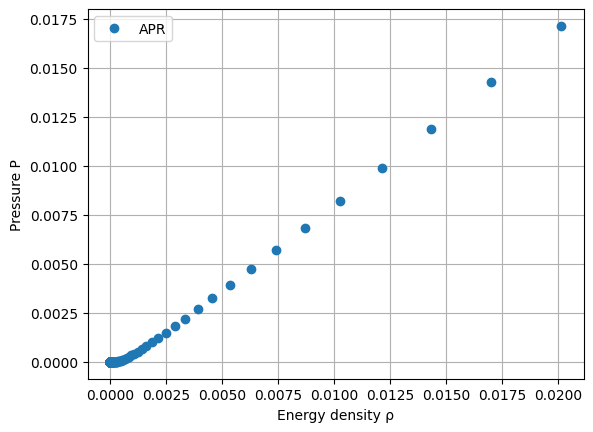

In [2]:
P_data, E_data = np.loadtxt(r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\EoS_HS(DD2)(with electrons)_clean_geometric.txt", unpack=True, skiprows=1)

#Create spline
PfromE = CubicSpline(E_data, P_data, extrapolate=True)    #Pressure from energy
EfromP = CubicSpline(P_data, E_data, extrapolate=True)    #Energy density(rho) from pressure

plt.plot(E_data, PfromE(E_data),"o", label = "APR") 
plt.xlabel("Energy density ρ")
plt.ylabel("Pressure P")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
dPdE = np.gradient(P_data, E_data)
dPdE_from_E = CubicSpline(E_data, dPdE,extrapolate=True)

dEdP = np.gradient(E_data, P_data)
dEdP_from_P = CubicSpline(P_data, dEdP,extrapolate=True)

#dPdE_from_E = PfromE.derivative() - derivatives behave badly when doing it this way

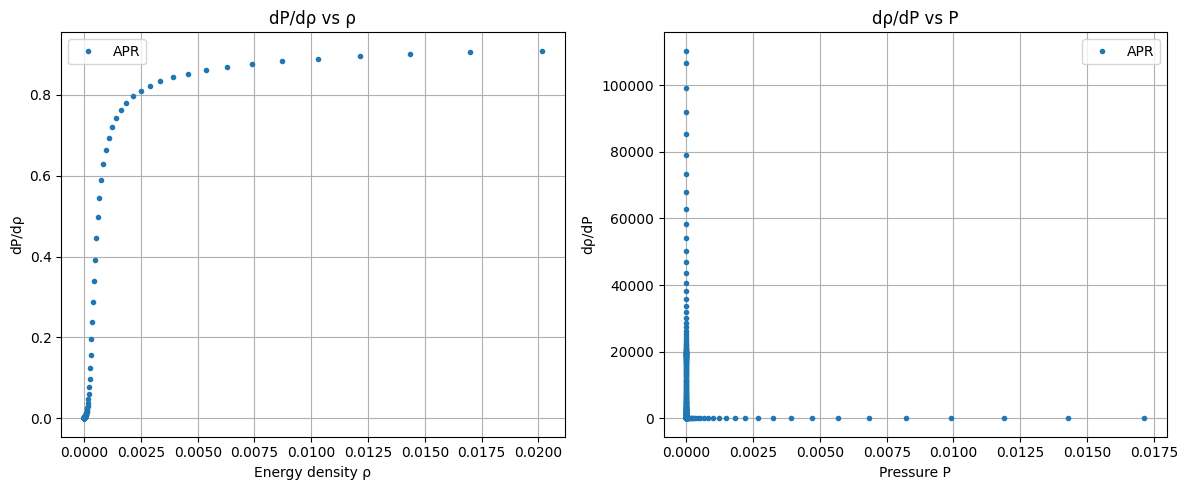

In [4]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# dP/dE
ax[0].plot(E_data,dPdE_from_E(E_data),".", label="APR")
ax[0].set_xlabel("Energy density ρ")
ax[0].set_ylabel("dP/dρ")
ax[0].set_title("dP/dρ vs ρ")
ax[0].legend()
ax[0].grid(True)


# dE/dP
ax[1].plot(P_data, dEdP_from_P(P_data),".", label="APR")
ax[1].set_xlabel("Pressure P")
ax[1].set_ylabel("dρ/dP")
ax[1].set_title("dρ/dP vs P")
#ax[1].set_xlim(0,0.0001)
ax[1].legend()
ax[1].grid(True)


plt.tight_layout()
plt.show()

# TOV Equations - anisotropy

From our analysis,

$$
\begin{align}
S_{\mu\nu}=-2c_3\kappa^2\Bigl(s_\alpha s^\alpha g_{\mu\nu}-2s_\mu s_\nu\Bigr)
\end{align}
$$

$$
\begin{align}
S_{\mu\nu}=-2c_3\kappa^2 q \left(\frac{1+2\chi^2}{3}(g_{\mu\nu} + u_{\mu}u_{\nu})-u_\mu u_\nu-2\chi^2  n_\mu n_\nu\right)
\end{align}
$$

And the energy momentum tensor for a perfect isotropic fluid is:
$$
T_{\mu\nu} = (\rho + P)u_{\mu}u_{\nu}  + p\,g_{\mu\nu}
$$


Therefore, the total energy momentum tensor is:

$$
\begin{equation}
T^{*}_{\mu\nu} = T_{\mu\nu} + \kappa S_{\mu\nu} 
\end{equation}
$$

$$
\begin{equation}
T^{*}_{\mu\nu} = \Big(\rho + 2c_3\kappa q + p -2c_3 \kappa \frac{1+2\chi^2}{3}\Big)u_{\mu}u_{\nu} + (4c_3 \kappa q \chi^2)n_{\mu}n_{\nu} + \Big(p - 2c_3 \kappa q \frac{1+2\chi^2}{3}\Big)\,g_{\mu\nu} 
\end{equation}
$$


Now comparing with the energy momentum tensor of a static, spherically symmetric anisotropic fluid, 
$$
T^{*}_{\mu\nu} = (\rho + p_{t})u_{\mu}u_{\nu} + (p_r - p_{t})n_{\mu}n_{\nu} + p_{t}\,g_{\mu\nu}
$$

where $p_{t}$ and $p_r$ are the tangential and radial pressures, and $n^{\mu}$ is the unit radial spacelike vector satisfying:

$$
n^{\mu}n_{\mu} = 1, \qquad u^{\mu}n_{\mu} = 0
$$

We can see that:

$$
\begin{align}
\rho_{\mathrm{eff}}=\rho+2c_3\kappa q, \quad p_{r, \mathrm{eff}}=p-2c_3\kappa q \frac{1-4\chi^2}{3}, \quad p_{t, \mathrm{eff}}=p-2c_3\kappa q \frac{1+2\chi^2}{3}
\end{align} 
$$

In Schwarzschild coordinates, the background metric is:

$$
ds^2 = g^{(0)}_{\mu\nu} dx^{\mu} dx^{\nu}
= -e^{\nu(r)} dt^2 + e^{\lambda(r)} dr^2 + r^2 d\theta^2 + r^2 \sin^2\theta \, d\phi^2
$$

And the modified TOV equations are:

$$
\frac{dp_{r, \mathrm{eff}}}{dr}
=
-\frac{(\rho_{\mathrm{eff}} + p_{r, \mathrm{eff}})\left(m + 4\pi r^3 p_{r, \mathrm{eff}}\right)}{r(r-2m)}
- \frac{2}{r}(p_{r, \mathrm{eff}} - p_{t, \mathrm{eff}})
$$

$$
p_{r, \mathrm{eff}} - p_{t, \mathrm{eff}} = 4c_3 \kappa q \chi^2
$$

$$
\frac{dm}{dr} = 4\pi r^2 \rho_{\mathrm{eff}}
$$

$$
\frac{d\nu}{dr}
=
\frac{m + 4\pi r^3 p_{r, \mathrm{eff}}}{r(r-2m)}
$$


Since the equation of state is defined with respect to the physical pressure and energy density, we move back to $p$ and $\rho$

$$
\frac{dp}{dr}
=
-\left(1-2c_3\kappa\frac{1-4\chi^2}{3}
\frac{d\rho}{dp}
\frac{dq}{d\rho}\right)^{-1}
\Bigg[
\frac{(p+\rho+4c_3\kappa q (\frac{1 + 2 \chi^2}{3}))
\left(m + 4\pi r^3 \Big(p-2c_3\kappa q \frac{1-4\chi^2}{3}\Big)\right)}
{r(r-2m)}
+
\frac{8c_3\kappa q \chi^2}{r}
+
\frac{16c_3\kappa q \chi}{3}\frac{d\chi}{dr}
\Bigg]
$$

$$
\begin{align}
\frac{dm}{dr} = 4\pi r^2 \rho + 8\pi r^2c_3\kappa q
\end{align}
$$

For the isotropic case, $\chi = 0$

$$
\frac{dp}{dr}
=
-\left(1-\frac{2c_3\kappa}{3}
\frac{d\rho}{dp}
\frac{dq}{d\rho}\right)^{-1}
\Bigg[\frac{
(p+\rho+\frac{4c_3\kappa q}{3})
\left(m+4\pi r^3
\left(p-\frac{2c_3\kappa q}{3}\right)\right)
}{r(r-2m)}
\Bigg]
$$

$$
\begin{align}
\frac{dm}{dr} = 4\pi r^2 \rho + 8\pi r^2c_3\kappa q
\end{align}
$$

q is defined as follows:

$$
q = \frac{1}{4}(\hbar c n)^2
\tag{1}
$$

By thermodynamic analysis (looking at adiabatic compression):

$$
\frac{dn}{n} = \frac{d\rho}{\rho + p(\rho)}
\tag{1}
$$

$$
\frac{dn}{d\rho} = \frac{n}{\rho + p(\rho)}
\tag{2}
$$


Separate variables:

$$
\frac{1}{n}\frac{dn}{d\rho} = \frac{1}{\rho + p(\rho)}
$$

Integrating:

$$
\ln n = \int \frac{d\rho}{\rho + p(\rho)} + C
$$

$$
n(\rho) = n_0 \exp\left(\int_{\rho_0}^{\rho}
\frac{d\rho'}{\rho' + p(\rho')}
\right)
$$

$n_0$ can be absorbed inside $c_3$, so we work simply with 

$$
n(\rho) = \exp\left(\int_{\rho_0}^{\rho}
\frac{d\rho'}{\rho' + p(\rho')}
\right)
$$

In [5]:
# Value of the fundamental constants in geom units:

hbar = 2.616*10**(-76) 

#hbar value in km^2 in geometric units

k = 8*np.pi 

#kappa value in geometric units

cval = 1.0

#c value in geometric units


In [6]:
from scipy.integrate import cumulative_trapezoid #Use for integration

integrand = 1/(E_data+P_data)

I = cumulative_trapezoid(integrand,E_data,initial=0)

n_data = np.exp(I)

# Replacing terminology at this point for consistency with eqns: E -> rho

# Interpolating function, n = n(rho)

n_from_rho = CubicSpline(E_data,n_data)

# Define dn/drho 

def dn_drho_from_rho(rho):
    n = n_from_rho(rho)
    p = PfromE(rho)
    dn_drho_val = n/(rho+p)
    return dn_drho_val

#Define dq/drho which appears in the TOV equations

def dq_drho_from_rho(rho):
    n = n_from_rho(rho)
    dn_drho_val = dn_drho_from_rho(rho)
    dq_drho_val = (1/2)*(hbar**2)*(cval**2)*n*dn_drho_val
    return dq_drho_val

In [57]:
def c3(a1, a2, a3, b1, b2, N):
    term1 = -8*(4 + 2*a1 + a2) / ((4 + 2*a1 + a2)**2 + 16*b1**2)

    denom2 = (16 
              + 4*a1**2 
              - 2*a1*(10 + a2 - 3*a3) 
              - 6*a3
              - 2*a2*(-7 + a2 + 3*a3)
              + (4*b1 - 3*b2)**2)

    term2 = -(-8 + 2*a1 + a2 + 3*a3) / denom2

    c3value1 = (1/3)*(term1 + term2) #can use this to see contribution by a certain combination of parameter values
    
    c3value2 = N/(hbar**2)
    
    return c3value2


def q(rho):
    n = 1.0
    qvalue = (1/4)*(hbar**2)*(n_from_rho(rho))**2
    return qvalue

# Taking R = 50.0, because this is the maximum bound for integration, ensures chi is between 0 and 1
# No physical motivation - requirement put in by hand

def χ(r,χtype):
    Rl = 50.0
    Rtan = 50.0
    if χtype=="zero":
        χvalue = 0
    elif χtype=="linear":
        χvalue = (1/Rl) * r 
    elif χtype=="tanh":
        χvalue = np.tanh(r/Rtan) 
    
    return χvalue

def dχ_dr(r,χtype):
    Rl = 50.0
    Rtan = 50.0
    if χtype=="zero":
        χvalue = 0
    elif χtype=="linear":
        χvalue = (1/Rl) 
    elif χtype=="tanh":
        χvalue = 1/((np.cosh(r/Rtan))**2)
    
    return χvalue

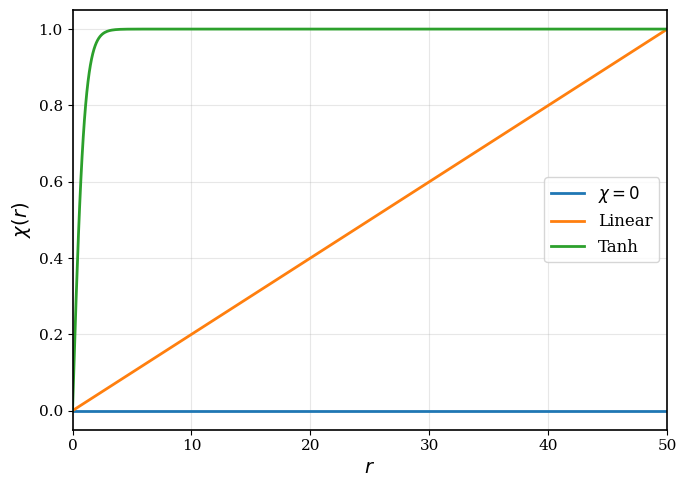

In [50]:
# Possible polarization profiles:

r_vals = np.linspace(0,50,500)

chi_zero = []
chi_linear = []
chi_tanh = []

for i in r_vals:
    chi_zero.append(χ(i,"zero"))
    chi_linear.append(χ(i,"linear"))
    chi_tanh.append(χ(i,"tanh"))

plt.figure(figsize=(7,5))

plt.plot(r_vals, chi_zero, label=r'$\chi=0$', linewidth=2)
plt.plot(r_vals, chi_linear, label=r'Linear', linewidth=2)
plt.plot(r_vals, chi_tanh, label=r'Tanh', linewidth=2)

plt.xlabel(r'$r$', fontsize=14)
plt.ylabel(r'$\chi(r)$', fontsize=14)

plt.xlim(0,50)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

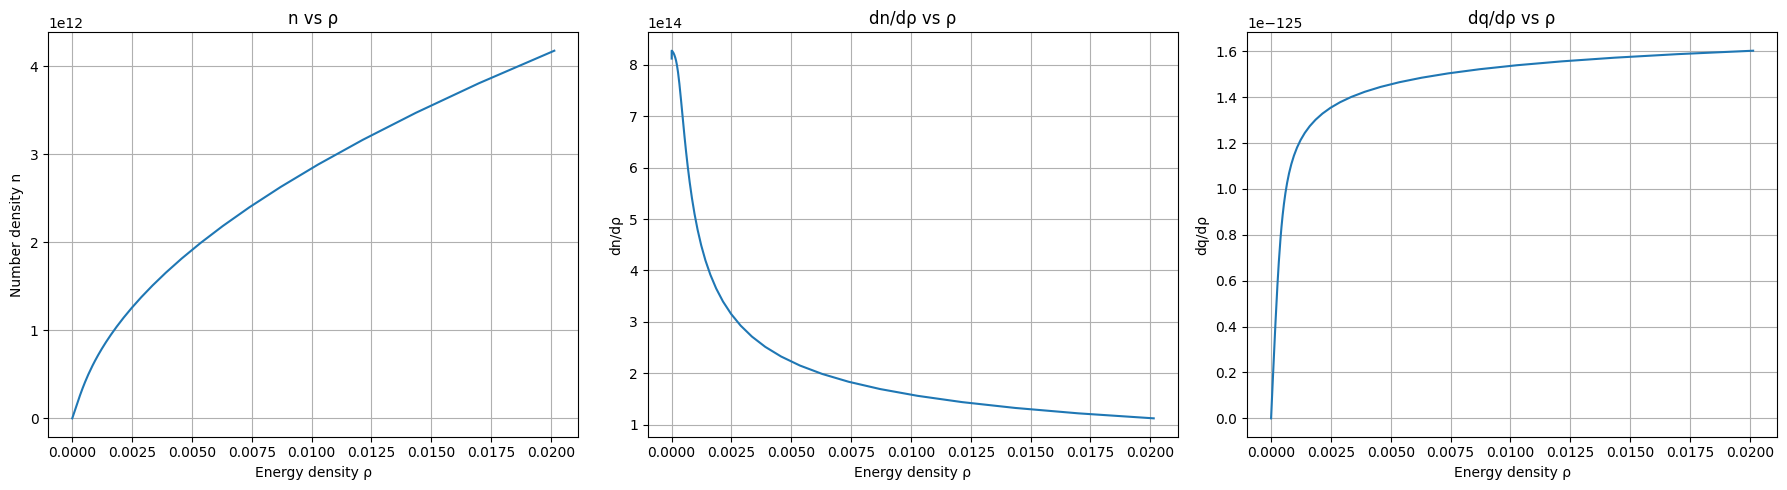

In [9]:
#Plots:

rho_data = E_data

fig, ax = plt.subplots(1,3, figsize=(18,5))

# n vs ρ
ax[0].plot(rho_data, n_from_rho(rho_data))
ax[0].set_xlabel("Energy density ρ")
ax[0].set_ylabel("Number density n")
ax[0].set_title("n vs ρ")
ax[0].grid(True)


# dn/dρ vs ρ
ax[1].plot(rho_data, dn_drho_from_rho(rho_data))
ax[1].set_xlabel("Energy density ρ")
ax[1].set_ylabel("dn/dρ")
ax[1].set_title("dn/dρ vs ρ")
ax[1].grid(True)


# dq/dρ vs ρ
ax[2].plot(rho_data, dq_drho_from_rho(rho_data))
ax[2].set_xlabel("Energy density ρ")
ax[2].set_ylabel("dq/dρ")
ax[2].set_title("dq/dρ vs ρ")
ax[2].grid(True)


plt.tight_layout()
plt.show()

In [10]:
# Physical quantities 

def tov_rhs_EC(r, y, χtype, a1, a2, a3, b1, b2, N):

    p, m = y
    
    if p <= 0:
        return [0,0]

    # terms
    c3val = c3(a1,a2,a3,b1,b2,N)
    rho = EfromP(p)
    qval = q(rho)
    χval = χ(r,χtype)

    # derivative terms
    drhodp = dEdP_from_P(p)
    dqdrho = dq_drho_from_rho(rho)
    dχdrval = dχ_dr(r,χtype)
    

    prefactor = 1/(1 - 2*c3val*k*(1-4*χval**2)/3 * drhodp * dqdrho)

    t1 = (rho + p + 4*c3val*k*qval*(1+2*χval**2)/3)
    t2 = (m + 4*np.pi*r**3*(p - 2*c3val*k*qval*(1-4*χval**2)/3 ))
    
    term1 = t1*t2/(r*(r-2*m))

    term2 = (1/r)*(8*c3val*k*qval*χval**2)
    
    term3 = (1/3)*(16*c3val*k*qval*χval*dχdrval)

    dpdr = -prefactor*(term1 + term2 + term3)

    dmdr = 4*np.pi*r**2*(rho + 2*c3val*k*qval)

    return [dpdr, dmdr]

def surface_reached(r, y, *args):
    p = y[0]
    return p - 1e-15

surface_reached.terminal = True
surface_reached.direction = -1

The prefactor for the $\frac{dp}{dr}$ equation is: 
$$
-\left(1-2c_3\kappa\frac{1-4\chi^2}{3}
\frac{d\rho}{dp}
\frac{dq}{d\rho}\right)^{-1}
$$

$\chi$ is already of order unity, now we need to pick $c_3$ such that $\frac{2 \kappa c_3}{3}\frac{d\rho}{dp}
\frac{dq}{d\rho}$ is also order unity. 

Also, $c_3 = \frac{N}{\hbar^2}$. We need to find appropriate N values. 

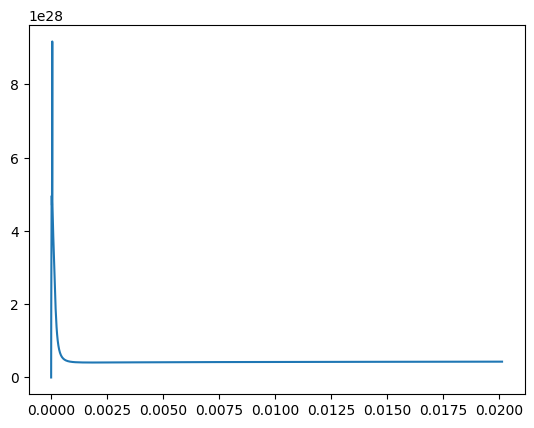

In [11]:
plt.plot(rho_data, dEdP_from_P(P_data) * dq_drho_from_rho(rho_data)/(hbar**2)*(2*k/3))

The peak is of order $10^{30}$, so $N$ must be of the order $10^{-30}$ to produce a deviation of order unity (but not much larger, else the MR curves would be un-physical)

# TOV Solver

In [46]:
# Solve TOV for a given central pressure

def solve_tov_EC(P_c, χtype, a1, a2, a3, b1, b2, N):
    
    r0 = 1e-5  # Start close to center to avoid zero division error
    rmax = 50  # 50 km is much bigger than neutron star radii
    m0 = 1e-15 #m prop to r^3
    y0 = [P_c, m0]

    sol = solve_ivp(
        tov_rhs_EC,
        [r0, rmax], y0,
        args=(χtype, a1, a2, a3, b1, b2, N),
        method="LSODA",
        events=surface_reached,
        max_step=1e-3, #essential for smoothness - do not change from 1e-3
        rtol=1e-6, atol=1e-8
)
    
    if len(sol.t_events[0]) == 0:
        return None, None

    R = sol.t_events[0][0]           # Stellar radius defined at point where pressure = 0, i.e. P(r = R) = 0
    M = sol.y[1][-1]                 # Mass at that point i.e. m(r = R) = M
    return R, M

# Single plot - for quick diagnostic checks

In [37]:
# Generate Mass-Radius data
central_pressures = np.logspace(-6, -1.5, 40) #Always use logspace for central pressure data - each number is uniformly spaced in power

radii = []
masses = []

i=1
for P_c in central_pressures:
    R, M = solve_tov_EC(P_c, "zero", 1, 1, 1, 1, 1, -(0.5)*1e-28)
    if R is not None and M is not None:
        radii.append(R)
        masses.append(M)
        print(f"Progress: {i}/{len(central_pressures)}".ljust(20), end="\r", flush=True)
        i = i+1
    elif R is None and M is None:
        print(f"Progress: {i}/{len(central_pressures)}".ljust(20), end="\r", flush=True)
        i = i+1
print("\nDONE!")
        
# Convert to km and solar masses for plotting
radii_km = np.array(radii)
masses_Msun = np.array(masses) / 1.4766  # Convert from geometric to M_sun

#Note: some stellar models at higher central pressures might return None values, and hence will be skipped

#For GR:
#Changing max central pressure from 10 to 10^(-1.5), changes maximum mass from 2.1957928306481884 to 2.1964431074138555
#corr radius from 9.944600098110856 to 10.039688563607942
#corr central pressure from 0.0015199110829529332 to 0.0013688745095370807

Progress: 40/40     
DONE!


In [16]:
# Number of stellar models that integrated (Pressure went below tolerance within the integration bounds)

print(len(radii_km))

40


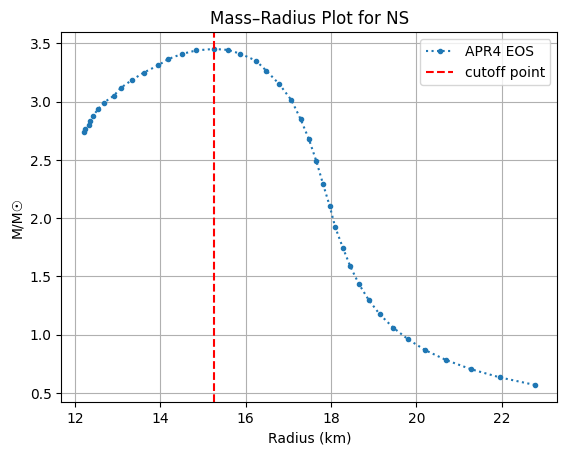

Maximum mass:  3.4518070234844154
Radius of maximum mass star:  15.257982069240127
Central pressure for maximum mass star:  0.0005878016072274912


In [38]:
# Plot M-R curve
plt.plot(radii_km, masses_Msun,".:", label="APR4 EOS")
plt.xlabel("Radius (km)")
plt.ylabel("M/M☉")

#We want to restrict the plot to the region after maximum mass (numerical errors before)

max_idx = np.argmax(masses_Msun) #index of element corr to max mass
max_mass = masses_Msun[max_idx]
max_mass_radius = radii_km[max_idx]
max_mass_central_pressure = central_pressures[max_idx]

plt.axvline(x=max_mass_radius, color='red', linestyle='--', label="cutoff point")
plt.title("Mass–Radius Plot for NS")
plt.grid(True)
plt.legend()
plt.show()

print("Maximum mass: ", max_mass)
print("Radius of maximum mass star: ", max_mass_radius)
print("Central pressure for maximum mass star: ", max_mass_central_pressure)

#For the tidal deformability plot - use the above value for maximum central pressure (to prevent numerical errors)
#P_central_max = 0.0013987131026472386

# Multiple plots - iterating over N values

## (i) $\chi = 0$ - zero polarization

In [47]:
central_pressures = np.logspace(-6, -1.5, 100)

N_values = [0, -(0.4)*1e-29, -(0.8)*1e-29, -(1)*1e-29, -(0.2)*1e-28]

MR_data_zero = {}

for N in N_values:

    radii = []
    masses = []

    print(f"\nRunning for N = {N}")

    i = 1

    for P_c in central_pressures:

        R, M = solve_tov_EC(P_c, "zero", 1, 1, 1, 1, 1, N)

        if R is not None and M is not None:
            radii.append(R)
            masses.append(M)

        print(f"Progress: {i}/{len(central_pressures)}".ljust(25),
              end="\r", flush=True)

        i += 1

    print("DONE!")

    radii_km = np.array(radii)
    masses_Msun = np.array(masses)/1.4766

    MR_data_zero[N] = (radii_km, masses_Msun)


Running for N = 0
DONE!ess: 100/100        

Running for N = -4e-30
DONE!ess: 100/100        

Running for N = -8e-30
DONE!ess: 100/100        

Running for N = -1e-29
DONE!ess: 100/100        

Running for N = -2.0000000000000002e-29
DONE!ess: 100/100        


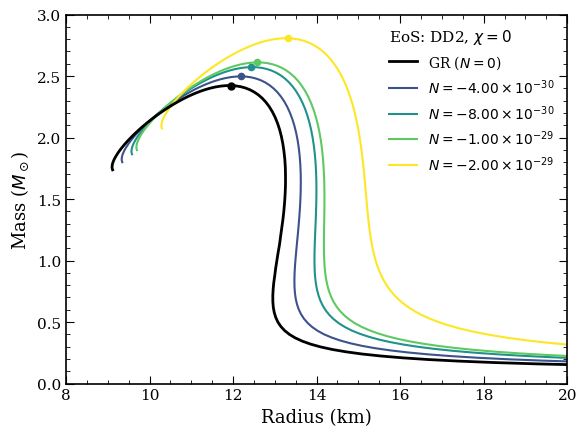

In [48]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth":1.2
})

plt.figure(figsize=(6,4.5))

colors = plt.cm.viridis(np.linspace(0,1,len(N_values)))

for i, N in enumerate(N_values):

    R, M = MR_data_zero[N]

    # GR case
    if abs(N) < 1e-40:

        plt.plot(
            R,
            M,
            linewidth=2,
            color='black',
            label="GR ($N=0$)",
            zorder=5
        )

        idx = np.argmax(M)

        plt.scatter(
            R[idx],
            M[idx],
            color='black',
            s=25,
            zorder=6
        )

    else:

        mantissa, exponent = f"{N:.2e}".split('e')

        label = rf"$N={mantissa}\times10^{{{int(exponent)}}}$"

        plt.plot(
            R,
            M,
            linewidth=1.5,
            color=colors[i],
            label=label
        )

        idx = np.argmax(M)

        plt.scatter(
            R[idx],
            M[idx],
            color=colors[i],
            s=20,
            zorder=3
        )


plt.xlabel(r"Radius (km)")
plt.ylabel(r"Mass ($M_\odot$)")

plt.xlim(8,20)
plt.ylim(0,3)

plt.tick_params(
    direction='in',
    which='both',
    top=True,
    right=True,
    length=6
)

plt.tick_params(
    which='minor',
    length=3
)

plt.minorticks_on()

plt.legend(
    frameon=False,
    loc="upper right"
)

plt.legend(
    frameon=False,
    loc="upper right",
    title=r"EoS: DD2, $\chi = 0$",
    title_fontsize=11,
    alignment='left'
)

plt.tight_layout()

# Save image as PDF
plt.savefig(
    r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\MRplot_DD2_zero.pdf",
    dpi=300,
    bbox_inches='tight'
)

# Save image as PNG
plt.savefig(
    r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\MRplot_DD2_zero.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## (ii) $\chi = \frac{r}{R}$ - linear

In [53]:
central_pressures = np.logspace(-6, -1.5, 100)

N_values = [0, -(0.4)*1e-29, -(0.8)*1e-29, -(1)*1e-29, -(0.2)*1e-28]

MR_data_linear = {}

for N in N_values:

    radii = []
    masses = []

    print(f"\nRunning for N = {N}")

    i = 1

    for P_c in central_pressures:

        R, M = solve_tov_EC(P_c, "linear", 1, 1, 1, 1, 1, N)

        if R is not None and M is not None:
            radii.append(R)
            masses.append(M)

        print(f"Progress: {i}/{len(central_pressures)}".ljust(25),
              end="\r", flush=True)

        i += 1

    print("DONE!")

    radii_km = np.array(radii)
    masses_Msun = np.array(masses)/1.4766

    MR_data_linear[N] = (radii_km, masses_Msun)


Running for N = 0
DONE!ess: 100/100        

Running for N = -4e-30
DONE!ess: 100/100        

Running for N = -8e-30
DONE!ess: 100/100        

Running for N = -1e-29
DONE!ess: 100/100        

Running for N = -2.0000000000000002e-29
DONE!ess: 100/100        


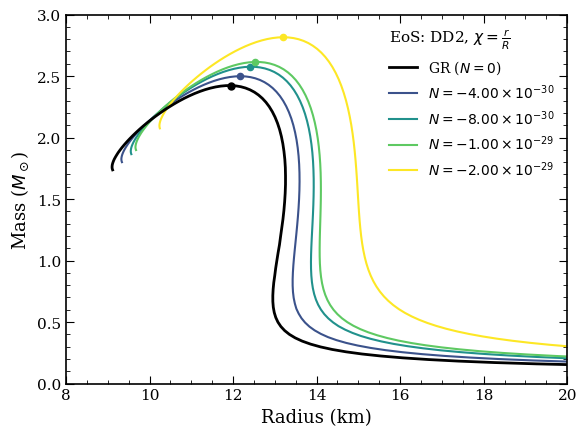

In [70]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth":1.2
})

plt.figure(figsize=(6,4.5))

colors = plt.cm.viridis(np.linspace(0,1,len(N_values)))

for i, N in enumerate(N_values):

    R, M = MR_data_linear[N]

    # GR case
    if abs(N) < 1e-40:

        plt.plot(
            R,
            M,
            linewidth=2,
            color='black',
            label="GR ($N=0$)",
            zorder=5
        )

        idx = np.argmax(M)

        plt.scatter(
            R[idx],
            M[idx],
            color='black',
            s=25,
            zorder=6
        )

    else:

        mantissa, exponent = f"{N:.2e}".split('e')

        label = rf"$N={mantissa}\times10^{{{int(exponent)}}}$"

        plt.plot(
            R,
            M,
            linewidth=1.5,
            color=colors[i],
            label=label
        )

        idx = np.argmax(M)

        plt.scatter(
            R[idx],
            M[idx],
            color=colors[i],
            s=20,
            zorder=3
        )


plt.xlabel(r"Radius (km)")
plt.ylabel(r"Mass ($M_\odot$)")

plt.xlim(8,20)
plt.ylim(0,3)

plt.tick_params(
    direction='in',
    which='both',
    top=True,
    right=True,
    length=6
)

plt.tick_params(
    which='minor',
    length=3
)

plt.minorticks_on()

plt.legend(
    frameon=False,
    loc="upper right"
)

plt.legend(
    frameon=False,
    loc="upper right",
    title=r"EoS: DD2, $\chi = \frac{r}{R}$",
    title_fontsize=11,
    alignment='left'
)

plt.tight_layout()

# Save image as PDF
plt.savefig(
    r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\MRplot_DD2_linear.pdf",
    dpi=300,
    bbox_inches='tight'
)

# Save image as PNG
plt.savefig(
    r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\MRplot_DD2_linear.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# (iii) $\chi = \text{tanh}\Big(\frac{r}{R}\Big)$ - hyperbolic tangent

In [58]:
central_pressures = np.logspace(-6, -2, 100)

N_values = [0, -(0.4)*1e-29, -(0.8)*1e-29, -(1)*1e-29, -(0.2)*1e-28]

MR_data_tanh = {}

for N in N_values:

    radii = []
    masses = []

    print(f"\nRunning for N = {N}")

    i = 1

    for P_c in central_pressures:

        R, M = solve_tov_EC(P_c, "tanh", 1, 1, 1, 1, 1, N)

        if R is not None and M is not None:
            radii.append(R)
            masses.append(M)

        print(f"Progress: {i}/{len(central_pressures)}".ljust(25),
              end="\r", flush=True)

        i += 1

    print("DONE!")

    radii_km = np.array(radii)
    masses_Msun = np.array(masses)/1.4766

    MR_data_tanh[N] = (radii_km, masses_Msun)


Running for N = 0
DONE!ess: 100/100        

Running for N = -4e-30
DONE!ess: 100/100        

Running for N = -8e-30
DONE!ess: 100/100        

Running for N = -1e-29
DONE!ess: 100/100        

Running for N = -2.0000000000000002e-29
DONE!ess: 100/100        


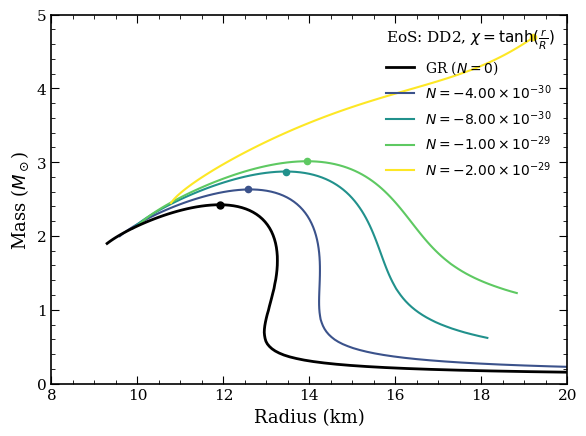

In [69]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth":1.2
})

plt.figure(figsize=(6,4.5))

colors = plt.cm.viridis(np.linspace(0,1,len(N_values)))

for i, N in enumerate(N_values):

    R, M = MR_data_tanh[N]

    # GR case
    if abs(N) < 1e-40:

        plt.plot(
            R,
            M,
            linewidth=2,
            color='black',
            label="GR ($N=0$)",
            zorder=5
        )

        idx = np.argmax(M)

        plt.scatter(
            R[idx],
            M[idx],
            color='black',
            s=25,
            zorder=6
        )

    else:

        mantissa, exponent = f"{N:.2e}".split('e')

        label = rf"$N={mantissa}\times10^{{{int(exponent)}}}$"

        plt.plot(
            R,
            M,
            linewidth=1.5,
            color=colors[i],
            label=label
        )

        idx = np.argmax(M)

        plt.scatter(
            R[idx],
            M[idx],
            color=colors[i],
            s=20,
            zorder=3
        )


plt.xlabel(r"Radius (km)")
plt.ylabel(r"Mass ($M_\odot$)")

plt.xlim(8,20)
plt.ylim(0,5)

plt.tick_params(
    direction='in',
    which='both',
    top=True,
    right=True,
    length=6
)

plt.tick_params(
    which='minor',
    length=3
)

plt.minorticks_on()

plt.legend(
    frameon=False,
    loc="upper right"
)

plt.legend(
    frameon=False,
    loc="upper right",
    title=r"EoS: DD2, $\chi = \text{tanh}(\frac{r}{R})$",
    title_fontsize=11,
    alignment='left'
)

plt.tight_layout()

# Save image as PDF
plt.savefig(
    r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\MRplot_DD2_tanh.pdf",
    dpi=300,
    bbox_inches='tight'
)

# Save image as PNG
plt.savefig(
    r"C:\Users\vashi\Jupyter Notebook\EC gravity\Data and Plots\MRplot_DD2_tanh.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()